In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error

df = pd.read_csv("insurance.csv")
df.head()



,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01


In [120]:
df.info()
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 104.8 KB
(1340, 10)


In [121]:
pd.set_option("display.float_format","{:.2f}".format)
df.head()
sns.set(style="whitegrid",palette="Set2",font_scale=1.1)

In [122]:
df.duplicated().sum()

np.int64(0)

In [123]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [124]:
df.dropna(inplace=True)
df.isnull().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [125]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


In [126]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


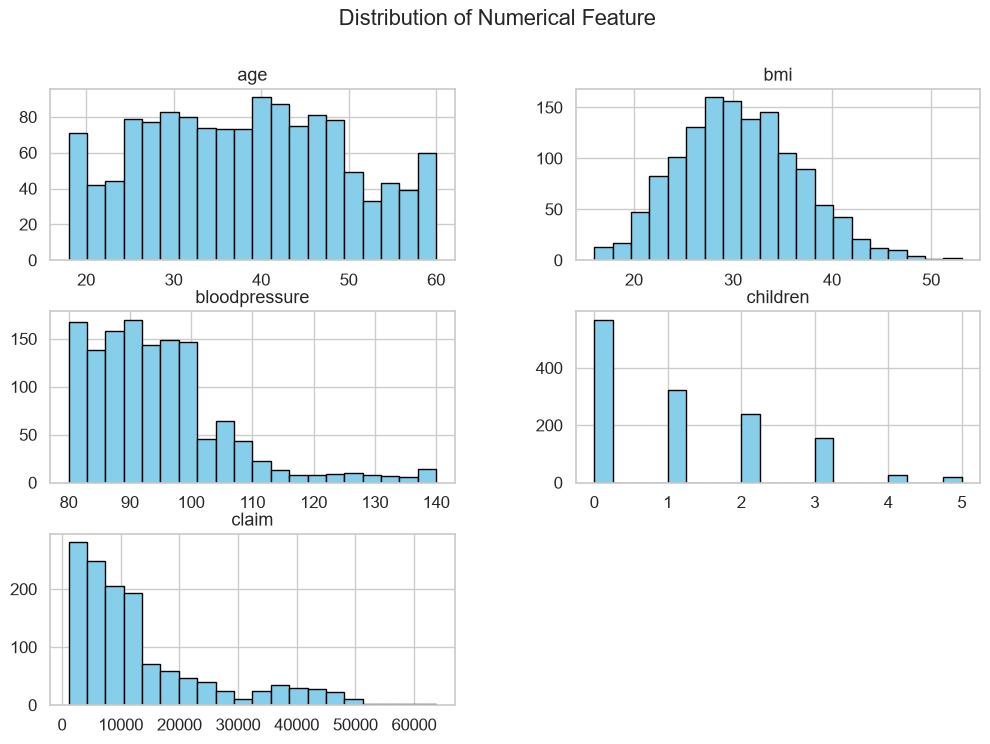

In [127]:
numerical_cols = ['age','bmi','bloodpressure','children','claim']

df[numerical_cols].hist(bins=20,figsize=(12,8),color = 'skyblue',edgecolor = 'black')
plt.suptitle("Distribution of Numerical Feature ")
plt.show()

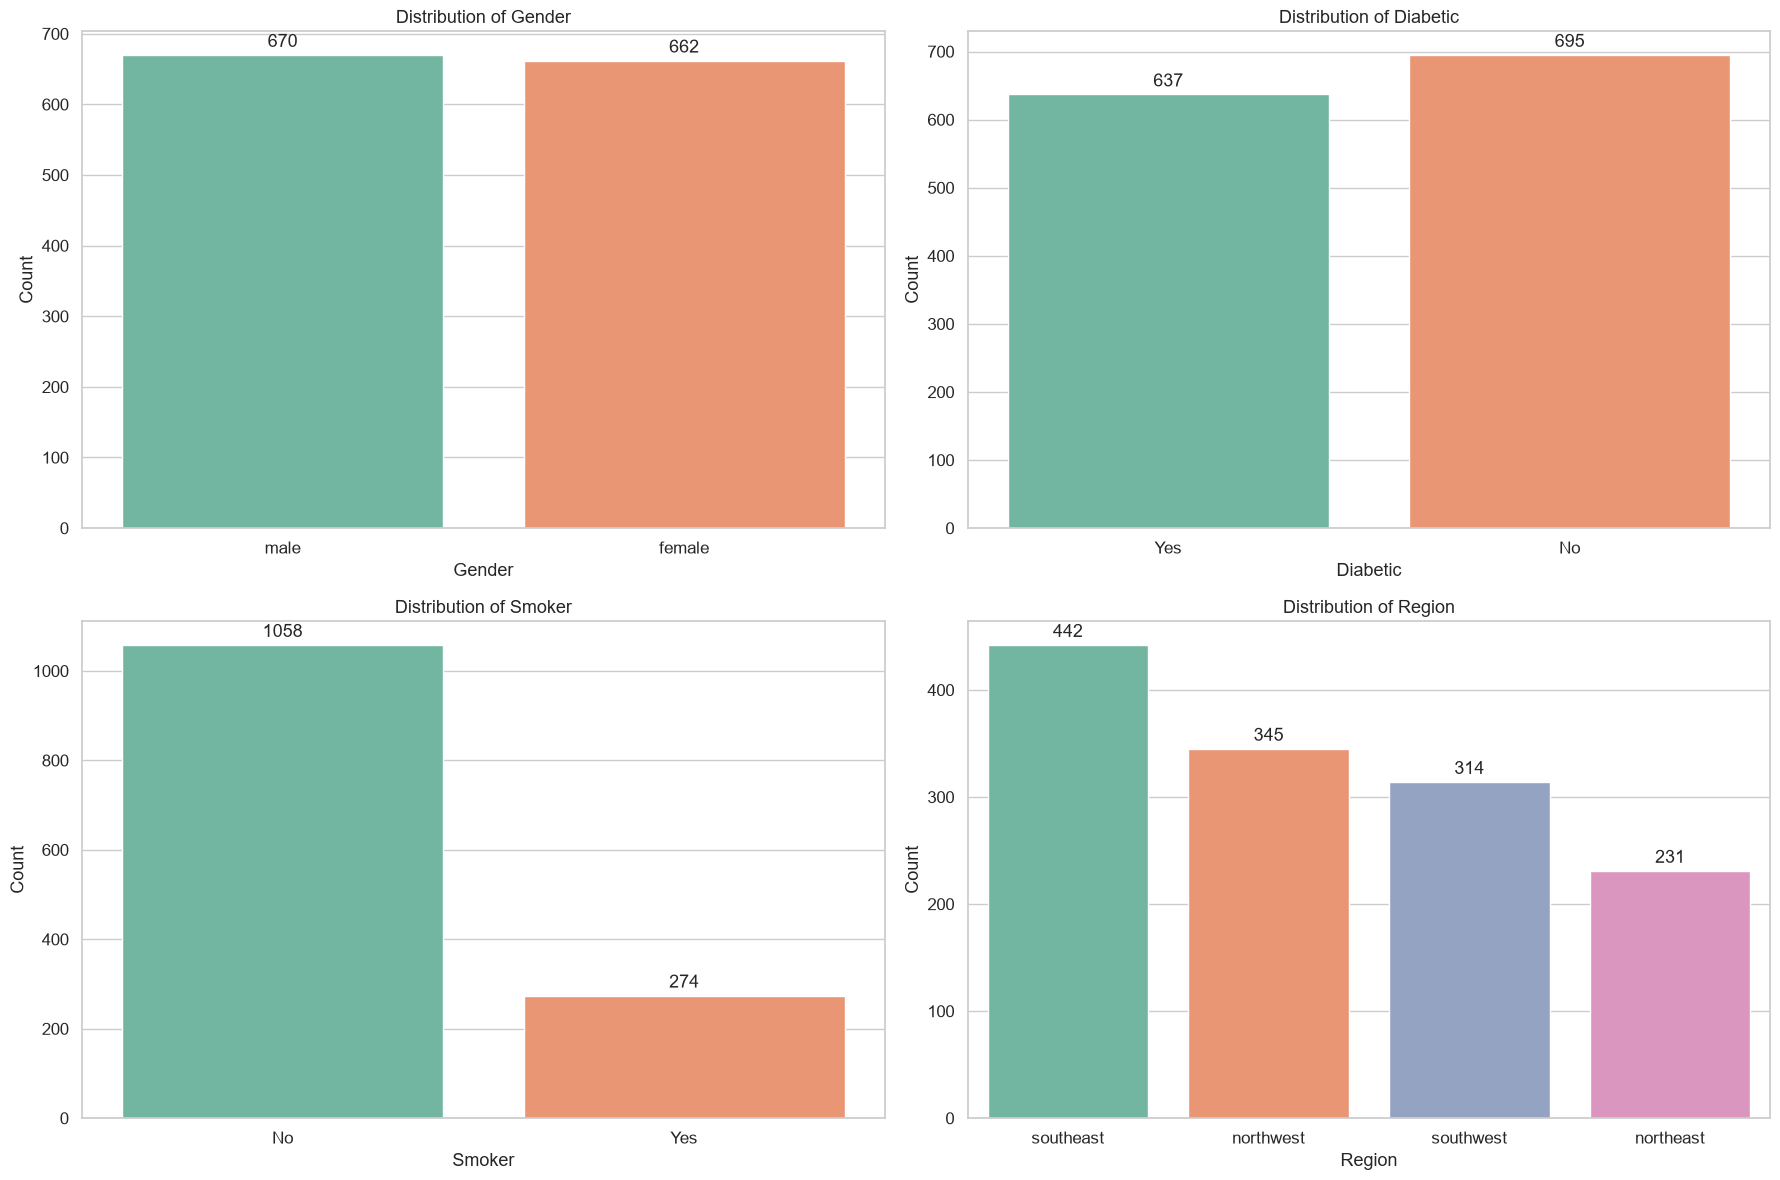

In [128]:
categorical_cols = ['gender','diabetic','smoker','region']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df, x=col, ax=ax,hue=col)

    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)

    ax.set_title(f"Distribution of {col.capitalize()}")
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [129]:
df.groupby(["gender",'smoker'])['claim'].mean()

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

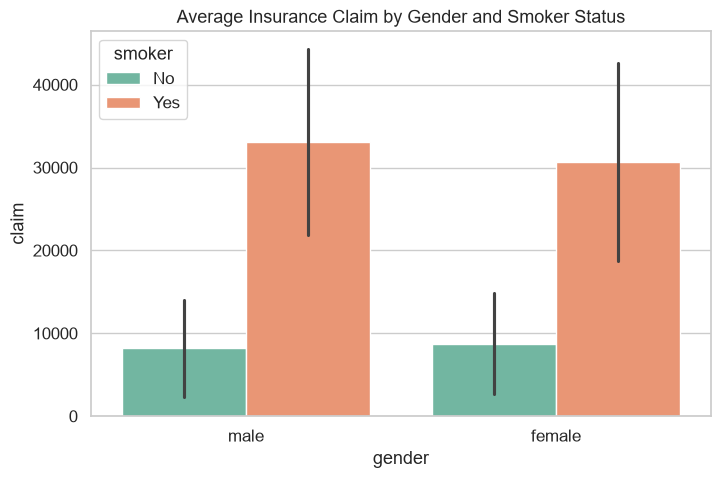

In [130]:
plt.figure(figsize=(8,5))

sns.barplot(data=df,x='gender',y = "claim",hue='smoker',estimator="mean",errorbar="sd")
plt.title("Average Insurance Claim by Gender and Smoker Status")
plt.show()


In [131]:
pivot_region_diabetic = df.groupby(["region",'diabetic'])["claim"].mean().unstack()
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


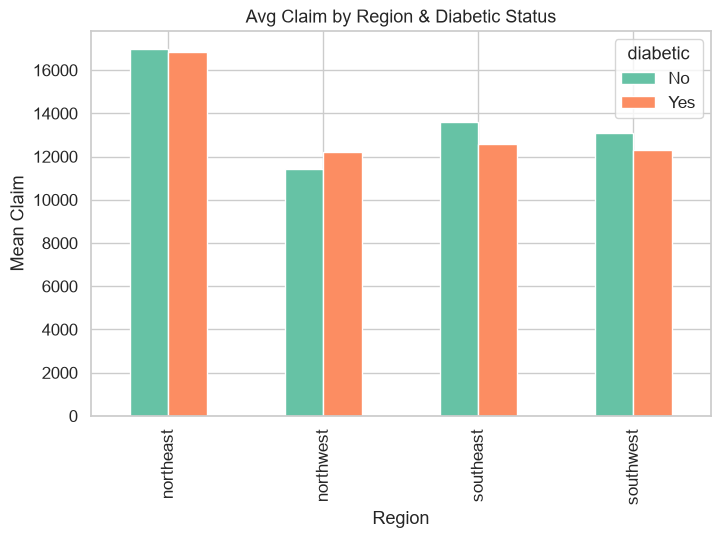

In [132]:
pivot_region_diabetic.plot(kind='bar',figsize=(8,5))
plt.xlabel('Region')
plt.ylabel('Mean Claim')
plt.title('Avg Claim by Region & Diabetic Status')
plt.show()


In [133]:
pivot_smoker_by_region = df.groupby(['region','smoker'])['claim'].mean().unstack()
pivot_smoker_by_region

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [134]:
pivot_table = pd.pivot_table(df,values='claim',columns='smoker',index='region',aggfunc='mean')
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [135]:
pivot_table_childrean_diabetic = pd.pivot_table(df,index='children',columns='diabetic',values='claim',aggfunc='mean')
pivot_table_childrean_diabetic

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


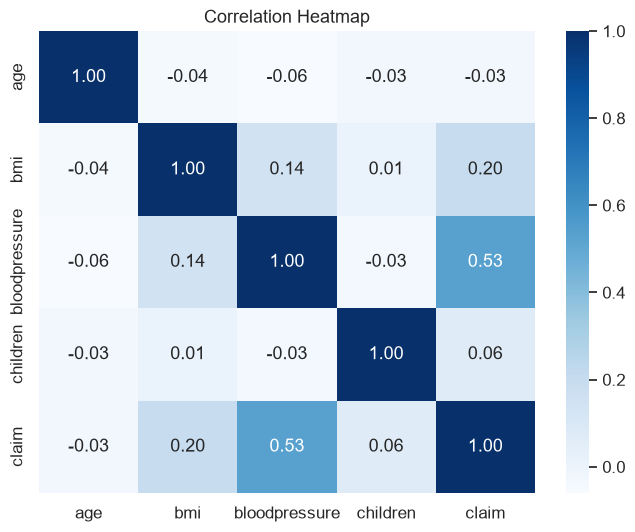

In [136]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols].corr(),annot=True,cmap='Blues',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

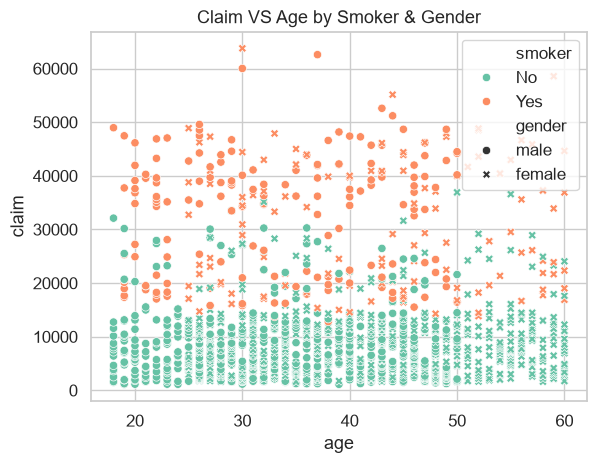

In [137]:
sns.scatterplot(df,x="age",y = "claim",hue="smoker",style="gender")
plt.title("Claim VS Age by Smoker & Gender")
plt.show()

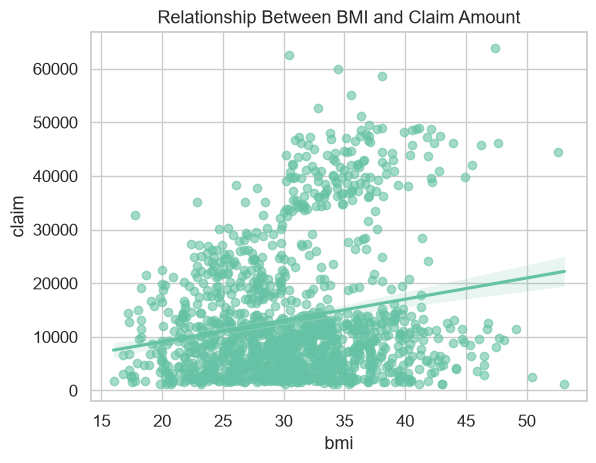

In [138]:
sns.regplot(df,x = 'bmi',y = 'claim',scatter_kws={"alpha":.6})
plt.title("Relationship Between BMI and Claim Amount")
plt.show()

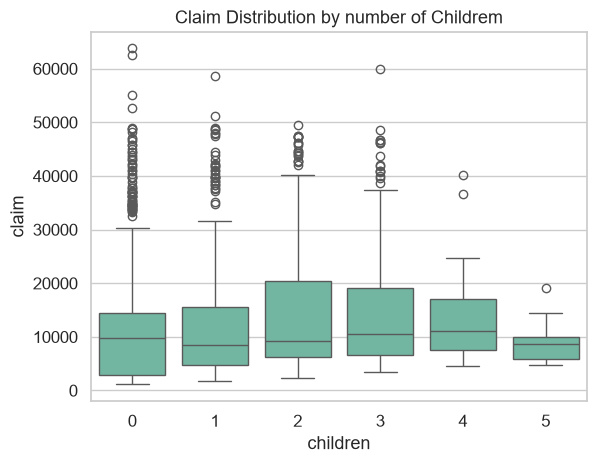

In [139]:
sns.boxplot(data=df,x = 'children', y = 'claim')
plt.title("Claim Distribution by number of Childrem")
plt.show()

In [140]:
df['age group'] = pd.cut(df['age'],bins=[0,18,30,45,60,100],labels=['<18','18-30','30-45','45-60','>60'])
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,30-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30


In [141]:
df['age group'].value_counts()

age group
30-45    553
45-60    383
18-30    380
<18       16
>60        0
Name: count, dtype: int64

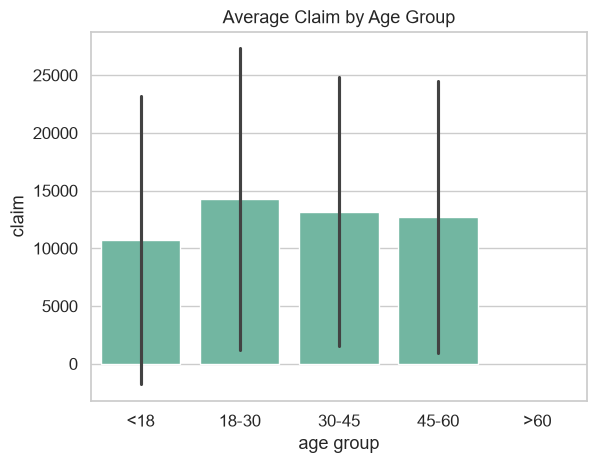

In [142]:
sns.barplot(df,x='age group',y = 'claim',estimator='mean',errorbar='sd')
plt.title("Average Claim by Age Group")
plt.show()

In [143]:
df['bmi_category'] = pd.cut(df['bmi'] , bins= [0,18.5,24.9,29.9,100],labels = ['underweight','normal','Overweight','Obeese'])
df['bmi_category'].value_counts()

bmi_category
Obeese         702
Overweight     387
normal         222
underweight     21
Name: count, dtype: int64

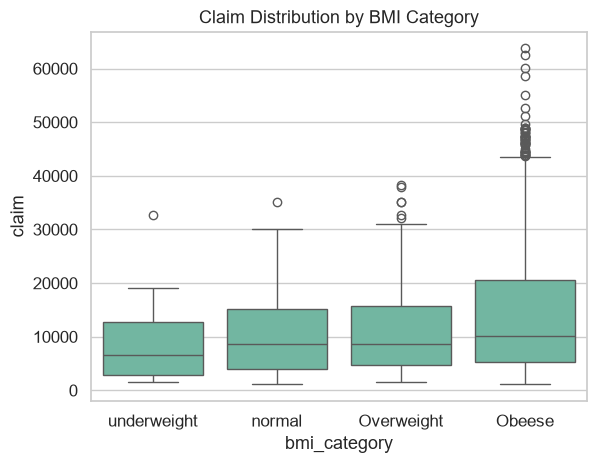

In [144]:
sns.boxplot(data=df,x='bmi_category',y = 'claim')
plt.title('Claim Distribution by BMI Category')
plt.show()

In [145]:
region_stats = df.groupby('region').agg(
    smoking_rate = ('smoker',lambda x: (x=='Yes').mean() * 100),
    mean_claim = ("claim","mean")
).reset_index()
region_stats

,region,smoking_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


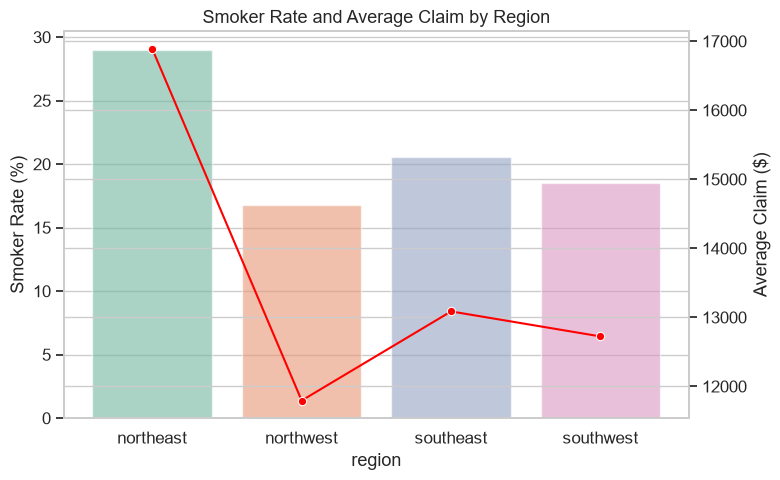

In [146]:
fig, ax1 = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=region_stats,
    x="region",
    y="smoking_rate",
    ax=ax1,
    hue="region",
    palette="Set2",
    legend=False,
    alpha=0.6
)

ax2 = ax1.twinx()

sns.lineplot(
    data=region_stats,
    x="region",
    y="mean_claim",
    ax=ax2,
    color="red",
    marker="o"
)

ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim ($)")
plt.title("Smoker Rate and Average Claim by Region")

plt.tight_layout()
plt.show()

In [147]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
import joblib

df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age group', 'bmi_category'],
      dtype='str')

In [174]:
X = df[['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children','smoker']]
y = df['claim']

cat_col = ['gender','diabetic','smoker']
label_encoders = {}

for col in cat_col:
    le = LabelEncoder()
    X[col]  = le.fit_transform(X[col])
    label_encoders[col] = le
    
    joblib.dump(le,f"label_encoder_{col}.pkl")

X = pd.get_dummies(X,columns=cat_col,drop_first=True)
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age group,bmi_category
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,30-45,normal
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30,Obeese
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30,Obeese
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30,Obeese
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30,Obeese


In [175]:
X.head()

,age,bmi,bloodpressure,children,gender_1,diabetic_1,smoker_1
0,39.00,23.20,91,0,True,True,False
1,24.00,30.10,87,0,True,False,False
7,19.00,41.10,100,0,True,False,False
8,20.00,43.00,86,0,True,False,False
9,30.00,53.10,97,0,True,False,False


In [176]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=.2)

num_col = ['age','bmi','bloodpressure','children']
scaler = StandardScaler()

X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.transform(X_test[num_col])


In [189]:
joblib.dump(scaler,f"scaler.pkl")

['scaler.pkl']

In [177]:
print(X_train.shape , y_train.shape)
print(X_test.shape,y_test.shape)

(1065, 7) (1065,)
(267, 7) (267,)


In [178]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRegressor

In [179]:
def evaluation_model(model,X_train,X_test,y_train,y_test):
    
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_pred,y_test)
    mae = mean_absolute_error(y_pred,y_test)
    r2 = r2_score(y_pred,y_test)
    rmse = np.sqrt(mean_squared_error(y_pred,y_test))
    
    return{"R2" : r2 , "MAE" : mae, "MSE": mse, "rmse": rmse }

In [180]:
results = {}

In [181]:
lr = LinearRegression()
lr.fit(X_train,y_train)
results['Linear Regression'] = evaluation_model(lr,X_train,X_test,y_train,y_test)
print("Linear Regression model Trained")


best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree = degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly,y_train)
    
    score = poly_lr.score(X_test_poly,y_test)
    
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree,poly,poly_lr)
        
degree , poly, poly_lr = best_poly_model

results[f"Polynomial Regression (deg = {degree})"] = evaluation_model(poly_lr,poly.fit_transform(X_train), poly.transform(X_test),y_train,y_test)
print("Polynomail Regression models are trained")


rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100,200],
    "max_depth": [None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf" : [1,2]
}

rf_grid = GridSearchCV(rf,rf_params,cv=3,scoring='r2' , n_jobs= -1, verbose= 0)
rf_grid.fit(X_train,y_train)
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluation_model(best_rf,X_train,X_test,y_train,y_test)

print("Random Forset traning is completed, best parameters:", rf_grid.best_params_)


svr = SVR()
svr_params = {
    "kernel": ["rbf", "linear"],
    "C": [1, 10, 50, 100, 500, 1000],
    "epsilon": [0.1, 1, 10, 50, 100],
    "gamma": ["scale", "auto"]
}

svr_grid = GridSearchCV(svr,svr_params,cv = 3 , scoring="r2" , n_jobs=-1,verbose=0)
svr_grid.fit(X_train,y_train)

best_svr = svr_grid.best_estimator_

results['SVR'] = evaluation_model(best_svr,X_train,X_test,y_train,y_test)
print("SVR training is Completed, best parameters:", svr_grid.best_params_)



xgb = XGBRegressor()
xgb_params = {
    "n_estimators" : [100,200],
    "max_depth" : [3,5,7],
    "learning_rate" : [.01 , .05 , .1],
    "subsample" : [.8,1]
}

xgb_grid = GridSearchCV(xgb,xgb_params,cv = 3, scoring='r2' , n_jobs=-1, verbose=0)
xgb_grid.fit(X_train,y_train)

best_xgb = xgb_grid.best_estimator_

results['XGB'] = evaluation_model(best_xgb,X_train,X_test,y_train,y_test)
print('XBG training is completed, Best Parameters:', xgb_grid.best_params_ )



Linear Regression model Trained
Polynomail Regression models are trained
Random Forset traning is completed, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR training is Completed, best parameters: {'C': 1000, 'epsilon': 100, 'gamma': 'scale', 'kernel': 'linear'}
XBG training is completed, Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [182]:
results 

{'Linear Regression': {'R2': 0.5818333241373388,
  'MAE': 5034.263198897409,
  'MSE': 40553181.35803283,
  'rmse': np.float64(6368.137982018985)},
 'Polynomial Regression (deg = 2)': {'R2': 0.7189971993487033,
  'MAE': 4426.321815178741,
  'MSE': 32317264.321579795,
  'rmse': np.float64(5684.827554251738)},
 'Random Forest': {'R2': 0.7978667277575245,
  'MAE': 3881.266878987941,
  'MSE': 25740124.915007036,
  'rmse': np.float64(5073.472668203411)},
 'SVR': {'R2': 0.46475160821930295,
  'MAE': 5029.815941049915,
  'MSE': 45519487.35873723,
  'rmse': np.float64(6746.813126116451)},
 'XGB': {'R2': 0.791930355802781,
  'MAE': 3820.898846558988,
  'MSE': 24159923.73689498,
  'rmse': np.float64(4915.2745332173445)}}

In [183]:
results_df = pd.DataFrame(results).T.sort_values(by='R2' , ascending=False)
results_df

,R2,MAE,MSE,rmse
Random Forest,0.80,3881.27,25740124.92,5073.47
XGB,0.79,3820.90,24159923.74,4915.27
Polynomial Regression (deg = 2),0.72,4426.32,32317264.32,5684.83
Linear Regression,0.58,5034.26,40553181.36,6368.14
SVR,0.46,5029.82,45519487.36,6746.81


In [184]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest" : best_rf,
    "SVR" : best_svr,
    "XGBoost" : best_xgb
}

In [185]:
best_r2 = results_df["R2"].max()
best_r2

np.float64(0.7978667277575245)

In [186]:
top_model = results_df[results_df['R2'] == best_r2]
top_model

,R2,MAE,MSE,rmse
Random Forest,0.80,3881.27,25740124.92,5073.47


In [187]:
best_model = models[top_model.index[0]]
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number

In [191]:
model = joblib.dump(best_model,"best_model.pkl")
print(f"Best Model selected : {top_model.index[0]}")

Best Model selected : Random Forest


In [193]:
print(best_model.feature_names_in_)

['age' 'bmi' 'bloodpressure' 'children' 'gender_1' 'diabetic_1' 'smoker_1']
